# 华泰金工全频段量价选股模型复现（LightGBM版）

## 项目框架搭建
本notebook演示从数据获取到回测的完整流程，使用沪深300成分股分钟数据计算两个简单因子，训练LightGBM模型。

### 注意事项
1. 确保已配置RQData用户名密码（在VeighNa Station中设置）
2. 数据下载可能需要较长时间，建议先使用少量股票测试
3. 因子计算部分需要根据研报实现27个高频因子，此处仅示例两个

In [2]:
# ============================================================================
# Windows 多进程问题修复
# ============================================================================
import multiprocessing
import sys
import warnings
warnings.filterwarnings('ignore')

# Windows 多进程配置
if sys.platform == 'win32':
    try:
        multiprocessing.set_start_method('spawn')
        print('多进程启动方法设置为 spawn (Windows兼容性)')
    except RuntimeError:
        pass  # 已经设置过

# ============================================================================
# 原始导入代码
# ============================================================================
# 1. 导入必要的库
import warnings

# vnpy相关
from vnpy.trader.setting import SETTINGS
from vnpy.trader.constant import Exchange, Interval
from vnpy.trader.object import BarData, HistoryRequest
from vnpy.trader.datafeed import get_datafeed
from vnpy.alpha.lab import AlphaLab
from vnpy.alpha.dataset import AlphaDataset, Segment, to_datetime
from vnpy.alpha.dataset.processor import (
    process_drop_na, process_fill_na, process_cs_norm, process_robust_zscore_norm
)

# 数据处理
import polars as pl


print('导入完成')

多进程启动方法设置为 spawn (Windows兼容性)
导入完成


In [3]:
# 2. 配置RQData数据服务
# 检查是否已配置用户名密码
print('当前数据服务配置:')
print('datafeed.username:', SETTINGS.get('datafeed.username', '未设置'))
print('datafeed.password:', SETTINGS.get('datafeed.password', '未设置'))

# 初始化数据服务
datafeed = get_datafeed()
print(f'数据服务类型: {datafeed.__class__.__name__}')

# 尝试初始化
if hasattr(datafeed, 'init'):
    inited = datafeed.init(output=print)
    print(f'初始化结果: {inited}')
else:
    print('数据服务无init方法，可能已自动初始化')

当前数据服务配置:
datafeed.username: license
datafeed.password: cilEC1HhQzr7r54PMYYmzzdKoIC6tItQ2c2TpCZPJOP22R7FftDt8evpY4pcb0_OiFTcngfpd9zs0LKslCQqoISMXbqG9dLk7L5999PgeVgi6iBD8ng2LoPGWgHjsYQb3jbvtYNLUtoukRyapl41y7sSFvI6vFnOrNoPnbwe-pg=T7HC7VpqgXpjVes9jwMsDJMxRLM_zhVDxCaSAhWcqYVSoI4HGD4xLpfp4hwVVZDZqlCQWmx9vHpdRBTI77QbNkdAIQVZdos1EgXK78APi6TjdTG3Zk_UiVgz_0MUhMq3rBSAXfLuolbc9mpRV95AK8afgK7jTzZaP--T9soxgfE=
数据服务类型: RqdataDatafeed
初始化结果: True


In [4]:
# 3. 创建AlphaLab实验室
import os
lab_path = os.path.join(os.getcwd(), 'lab')
lab = AlphaLab(lab_path)
print(f'AlphaLab路径: {lab_path}')

AlphaLab路径: C:\Users\86188\Desktop\MF\lab


In [5]:
# 4. 数据下载函数（修复时区问题）
def download_bars(symbol, exchange, start, end, interval, tz='Asia/Shanghai'):
    """
    下载K线数据并修复时区问题
    """
    from zoneinfo import ZoneInfo
    tz_sh = ZoneInfo(tz)
    start_dt = start.replace(tzinfo=tz_sh) if start.tzinfo is None else start.astimezone(tz_sh)
    end_dt = end.replace(tzinfo=tz_sh) if end.tzinfo is None else end.astimezone(tz_sh)
    
    req = HistoryRequest(
        symbol=symbol,
        exchange=exchange,
        start=start_dt,
        end=end_dt,
        interval=interval
    )
    
    bars = datafeed.query_bar_history(req, output=print)
    if bars:
        # 转换时区相关datetime为时区无关（本地时间）
        for bar in bars:
            if bar.datetime.tzinfo is not None:
                bar.datetime = bar.datetime.astimezone(tz_sh).replace(tzinfo=None)
    return bars

print('数据下载函数定义完成')

数据下载函数定义完成


In [6]:
# 5. 下载数据（示例：5只股票的分钟数据）
# 选择5只股票（沪深300成分股示例）
symbols = ['000001', '000002', '000063', '000069', '000100']
exchange = Exchange.SZSE
vt_symbols = [f'{symbol}.{exchange.value}' for symbol in symbols]

# 时间范围：2013-01-01 至 2026-03-27
from datetime import datetime
start = datetime(2023, 1, 1)
end = datetime(2026, 3, 27)
interval = Interval.MINUTE

print(f'准备下载 {len(vt_symbols)} 只股票的分钟数据')
print(f'时间范围: {start} 到 {end}')

# 循环下载
for vt_symbol in vt_symbols:
    print(f'下载 {vt_symbol} ...')
    bars = download_bars(vt_symbol.split('.')[0], exchange, start, end, interval)
    if bars:
        lab.save_bar_data(bars)
        print(f'  -> 保存 {len(bars)} 条K线')
    else:
        print(f'  -> 无数据')

print('下载完成')

准备下载 5 只股票的分钟数据
时间范围: 2023-01-01 00:00:00 到 2026-03-27 00:00:00
下载 000001.SZSE ...
  -> 保存 187200 条K线
下载 000002.SZSE ...
  -> 保存 187200 条K线
下载 000063.SZSE ...
  -> 保存 187200 条K线
下载 000069.SZSE ...
  -> 保存 187200 条K线
下载 000100.SZSE ...
  -> 保存 187200 条K线
下载完成


In [7]:
# 5. 加载数据
df = lab.load_bar_df(
    vt_symbols=vt_symbols,
    interval=interval,
    start=start,
    end=end,
    extended_days=0
)

if df is not None:
    print(f'数据形状: {df.shape}')
    print(df.head())
else:
    print('加载数据失败')

数据形状: (936000, 10)
shape: (5, 10)
┌────────────┬──────────┬──────────┬──────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ datetime   ┆ open     ┆ high     ┆ low      ┆ … ┆ turnover   ┆ open_inte ┆ vwap      ┆ vt_symbol │
│ ---        ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---        ┆ rest      ┆ ---       ┆ ---       │
│ datetime[μ ┆ f64      ┆ f64      ┆ f64      ┆   ┆ f64        ┆ ---       ┆ f64       ┆ str       │
│ s]         ┆          ┆          ┆          ┆   ┆            ┆ f64       ┆           ┆           │
╞════════════╪══════════╪══════════╪══════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 2023-01-03 ┆ 1.003039 ┆ 1.005319 ┆ 0.992401 ┆ … ┆ 9.5493022e ┆ 0.0       ┆ 11.150703 ┆ 000001.SZ │
│ 09:30:00   ┆          ┆          ┆          ┆   ┆ 7          ┆           ┆           ┆ SE        │
│ 2023-01-03 ┆ 1.0      ┆ 1.00152  ┆ 0.996201 ┆ … ┆ 1.483856e7 ┆ 0.0       ┆ 11.118381 ┆ 000001.SZ │
│ 09:31:00   ┆          ┆          ┆          ┆   ┆      

In [8]:
# 6. 数据清洗
# 去除缺失值
df_clean = df.drop_nulls(subset=['open', 'high', 'low', 'close', 'volume', 'turnover'])
print(f'清洗后形状: {df_clean.shape}')

# 检查数据连续性（按股票分组）
for vt_symbol in vt_symbols:
    sub = df_clean.filter(pl.col('vt_symbol') == vt_symbol)
    print(f'{vt_symbol}: {len(sub)} 条记录')

清洗后形状: (936000, 10)
000001.SZSE: 187200 条记录
000002.SZSE: 187200 条记录
000063.SZSE: 187200 条记录
000069.SZSE: 187200 条记录
000100.SZSE: 187200 条记录


In [9]:
# 7. 计算因子特征
# 因子1: 收益率 (close_t / close_{t-1} - 1)
# 因子2: 波动率 (high - low) / close

# 使用polars计算特征
# 首先确保数据按股票和时间排序
df_sorted = df_clean.sort(['vt_symbol', 'datetime'])

# 计算ret特征：收益率
ret_df = df_sorted.select(['datetime', 'vt_symbol', 'close'])
ret_df = ret_df.with_columns([
    ((pl.col('close') / pl.col('close').shift(1).over('vt_symbol')) - 1).alias('data')
])
ret_df = ret_df.select(['datetime', 'vt_symbol', 'data'])  # 只保留需要的列

# 计算volatility特征：波动率
volatility_df = df_sorted.select(['datetime', 'vt_symbol', 'high', 'low', 'close'])
volatility_df = volatility_df.with_columns([
    ((pl.col('high') - pl.col('low')) / pl.col('close')).alias('data')
])
volatility_df = volatility_df.select(['datetime', 'vt_symbol', 'data'])  # 只保留需要的列

# 基础数据（不包含因子）
df_base = df_sorted.select(['datetime', 'vt_symbol', 'open', 'high', 'low', 'close', 'volume', 'turnover'])

print('特征计算完成')
print(f'ret_df形状: {ret_df.shape}, 列: {ret_df.columns}')
print(f'volatility_df形状: {volatility_df.shape}, 列: {volatility_df.columns}')
print(f'基础数据形状: {df_base.shape}, 列: {df_base.columns}')


特征计算完成
ret_df形状: (936000, 3), 列: ['datetime', 'vt_symbol', 'data']
volatility_df形状: (936000, 3), 列: ['datetime', 'vt_symbol', 'data']
基础数据形状: (936000, 8), 列: ['datetime', 'vt_symbol', 'open', 'high', 'low', 'close', 'volume', 'turnover']


In [36]:
# 8. 创建AlphaDataset
# 划分训练集、验证集、测试集
train_start = '2023-01-01'
train_end = '2023-12-31'
valid_start = '2024-01-01'
valid_end = '2024-12-31'
test_start = '2025-01-01'
test_end = '2026-03-27'

dataset = AlphaDataset(
    df=df_base,
    train_period=(train_start, train_end),
    valid_period=(valid_start, valid_end),
    test_period=(test_start, test_end),
    process_type='append'
)


from functools import partial
# 添加数据预处理器
dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_norm, names=["label"], method="zscore"))
# 添加特征
# 添加预计算的特征（通过result参数）
dataset.add_feature('ret', result=ret_df)
dataset.add_feature('volatility', result=volatility_df)
# 因子1: 收益率 (close_t / close_{t-1} - 1)，使用ts_delay函数
# 因子2: 波动率 (high - low) / close

# 设置标签：下一期的收益率（使用ts_delay函数）
# 注意：需要确保数据按时间排序，这里使用polars的shift

dataset.set_label('(ts_delay(close, -1) / close) - 1')


# # 添加预处理器
# # 1. 删除标签缺失的行（最后一条数据没有未来收益率）
# dataset.add_processor('learn', lambda df: process_drop_na(df, names=['label']))  # 删除标签缺失的行
# # 2. 填充特征缺失值（用0填充），不填充标签
# dataset.add_processor('learn', lambda df: process_fill_na(df, fill_value=0.0, fill_label=False))  # 缺失值填充，只填充特征
# # 3. 稳健z-score标准化（使用训练集时间段拟合参数，避免未来信息泄露）
# dataset.add_processor('learn', lambda df: process_robust_zscore_norm(df, fit_start_time=train_start, fit_end_time=train_end, clip_outlier=True))  # 稳健z-score标准化
print(dataset.df)
print(dataset.feature_results)

print('数据集创建完成')


shape: (936_000, 8)
┌──────────────┬─────────────┬──────────┬──────────┬──────────┬──────────┬───────────┬─────────────┐
│ datetime     ┆ vt_symbol   ┆ open     ┆ high     ┆ low      ┆ close    ┆ volume    ┆ turnover    │
│ ---          ┆ ---         ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---         │
│ datetime[μs] ┆ str         ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64       ┆ f64         │
╞══════════════╪═════════════╪══════════╪══════════╪══════════╪══════════╪═══════════╪═════════════╡
│ 2023-01-03   ┆ 000001.SZSE ┆ 1.003039 ┆ 1.005319 ┆ 0.992401 ┆ 1.0      ┆ 8.5639e6  ┆ 9.5493022e7 │
│ 09:30:00     ┆             ┆          ┆          ┆          ┆          ┆           ┆             │
│ 2023-01-03   ┆ 000001.SZSE ┆ 1.0      ┆ 1.00152  ┆ 0.996201 ┆ 0.99848  ┆ 1.3346e6  ┆ 1.483856e7  │
│ 09:31:00     ┆             ┆          ┆          ┆          ┆          ┆           ┆             │
│ 2023-01-03   ┆ 000001.SZSE ┆ 0.99848  ┆ 1.00076  ┆ 0.996201 ┆ 0.99924

In [37]:
name = "300_lgb"
index_symbol: str = "000300.SSE"
interval: Interval = Interval.MINUTE

In [38]:
dataset.prepare_data()

2026-03-29 00:15:46 开始计算表达式因子特征


100%|██████████| 1/1 [00:05<00:00,  5.16s/it]

2026-03-29 00:15:52 开始合并结果数据因子特征



100%|██████████| 2/2 [00:00<00:00, 12.75it/s]


In [39]:
# 数据预处理
dataset.process_data()

In [40]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

In [41]:
# 加载模块
import numpy as np

from vnpy.alpha import Segment, AlphaDataset, AlphaModel

from vnpy.alpha.model.models.lgb_model import LgbModel

In [42]:
# 从文件缓存加载
dataset: AlphaDataset = lab.load_dataset(name)

In [43]:
# 创建模型对象
model: AlphaModel = LgbModel(seed=42)

In [44]:
# 使用数据集训练模型
model.fit(dataset)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001092 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 510
[LightGBM] [Info] Number of data points in the train set: 290400, number of used features: 2
[LightGBM] [Info] Start training from score -0.000002
[1]	train's l2: 2.61684e-06	valid's l2: 4.59382e-06
Training until validation scores don't improve for 50 rounds
[2]	train's l2: 2.59015e-06	valid's l2: 4.56587e-06
[3]	train's l2: 2.56837e-06	valid's l2: 4.54281e-06
[4]	train's l2: 2.55073e-06	valid's l2: 4.52309e-06
[5]	train's l2: 2.53624e-06	valid's l2: 4.50679e-06
[6]	train's l2: 2.52379e-06	valid's l2: 4.49296e-06
[7]	train's l2: 2.51391e-06	valid's l2: 4.48132e-06
[8]	train's l2: 2.50541e-06	valid's l2: 4.47107e-06
[9]	train's l2: 2.49874e-06	valid's l2: 4.4634e-06
[10]	train's l2: 2.4933e-06	valid's l2: 4.45668e-06
[11]	train's l

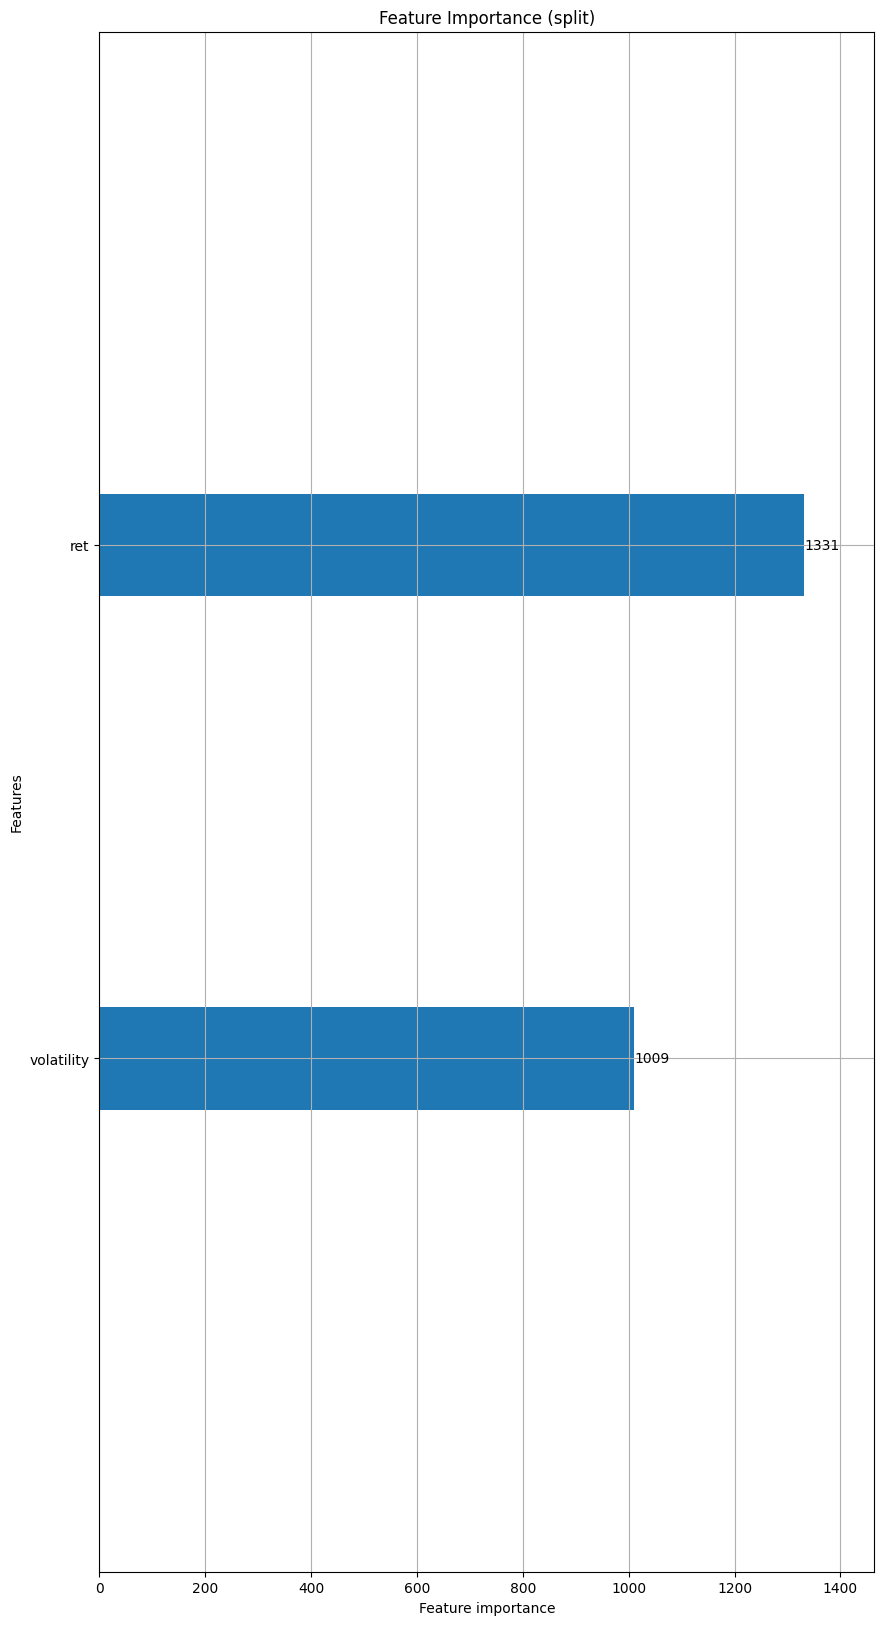

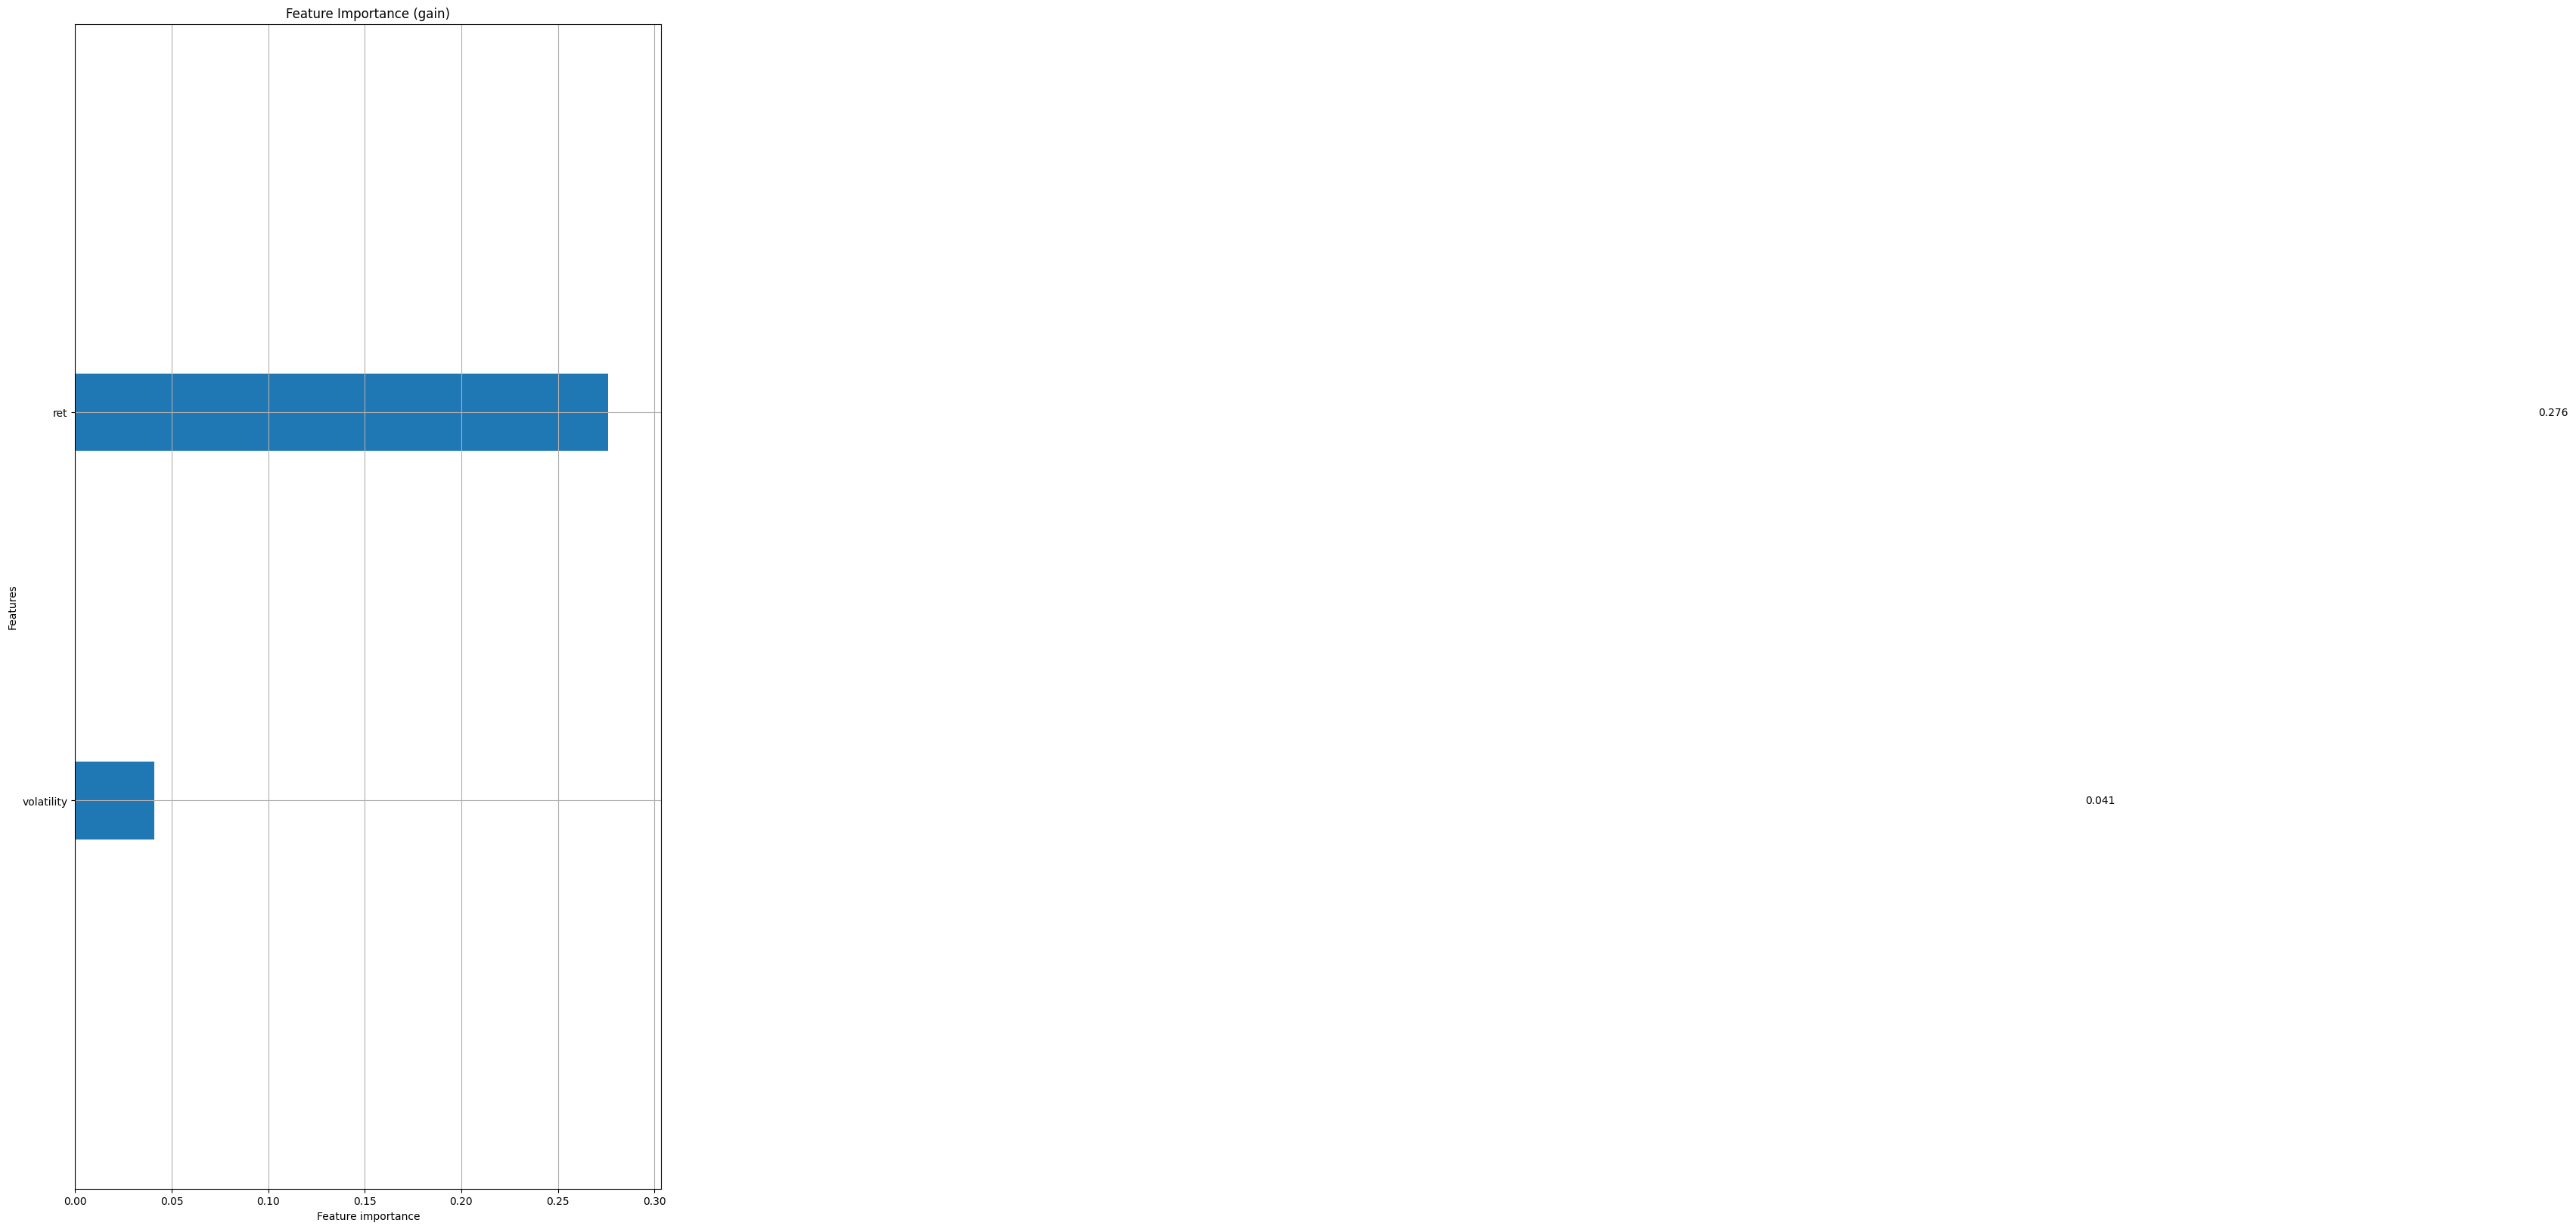

In [45]:
# 查看模型细节
model.detail()

In [46]:
# 保存模型
lab.save_model(name, model)

In [47]:
model: AlphaModel = lab.load_model(name)

In [80]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]
print(signal)

shape: (355_200, 3)
┌─────────────────────┬─────────────┬───────────┐
│ datetime            ┆ vt_symbol   ┆ signal    │
│ ---                 ┆ ---         ┆ ---       │
│ datetime[μs]        ┆ str         ┆ f64       │
╞═════════════════════╪═════════════╪═══════════╡
│ 2025-01-02 09:30:00 ┆ 000001.SZSE ┆ -0.000714 │
│ 2025-01-02 09:30:00 ┆ 000002.SZSE ┆ -0.000536 │
│ 2025-01-02 09:30:00 ┆ 000063.SZSE ┆ 0.000395  │
│ 2025-01-02 09:30:00 ┆ 000069.SZSE ┆ -0.000536 │
│ 2025-01-02 09:30:00 ┆ 000100.SZSE ┆ -0.000432 │
│ …                   ┆ …           ┆ …         │
│ 2026-03-26 14:59:00 ┆ 000001.SZSE ┆ -0.00011  │
│ 2026-03-26 14:59:00 ┆ 000002.SZSE ┆ 0.000479  │
│ 2026-03-26 14:59:00 ┆ 000063.SZSE ┆ 0.002157  │
│ 2026-03-26 14:59:00 ┆ 000069.SZSE ┆ -0.00011  │
│ 2026-03-26 14:59:00 ┆ 000100.SZSE ┆ 0.000386  │
└─────────────────────┴─────────────┴───────────┘


In [51]:
# 保存信号数据
lab.save_signal(name, signal)

In [52]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

import vnpy.alpha.strategy.strategies.equity_demo_strategy as equity_demo_strategy

In [53]:
# 重载策略类
importlib.reload(equity_demo_strategy)
EquityDemoStrategy = equity_demo_strategy.EquityDemoStrategy

In [54]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [57]:
# 添加回测参数配置
for vt_symbol in vt_symbols:
    lab.add_contract_setting(
        vt_symbol,
        long_rate=5/10000,
        short_rate=10/10000,
        size=1,
        pricetick=0.0001,
    )

In [79]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=vt_symbols,
    interval=Interval.MINUTE,
    start=datetime(2025, 1, 1),
    end=datetime(2026, 3, 27),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [77]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2026-03-29 00:52:50 开始加载历史数据


  0%|          | 0/5 [00:00<?, ?it/s]

2026-03-29 00:52:50 File C:\Users\86188\Desktop\MF\lab\daily\000001.SZSE.parquet does not exist
2026-03-29 00:52:50 File C:\Users\86188\Desktop\MF\lab\daily\000002.SZSE.parquet does not exist
2026-03-29 00:52:50 File C:\Users\86188\Desktop\MF\lab\daily\000063.SZSE.parquet does not exist
2026-03-29 00:52:50 File C:\Users\86188\Desktop\MF\lab\daily\000069.SZSE.parquet does not exist
2026-03-29 00:52:50 File C:\Users\86188\Desktop\MF\lab\daily\000100.SZSE.parquet does not exist


100%|██████████| 5/5 [00:00<00:00, 960.85it/s]

2026-03-29 00:52:50 部分合约历史数据为空：['000001.SZSE', '000002.SZSE', '000063.SZSE', '000069.SZSE', '000100.SZSE']
2026-03-29 00:52:50 所有历史数据加载完成
2026-03-29 00:52:50 策略初始化完成
2026-03-29 00:52:50 开始回放历史数据
2026-03-29 00:52:50 历史数据回放结束
2026-03-29 00:52:50 开始计算逐日盯市盈亏
2026-03-29 00:52:50 成交记录为空，无法计算
2026-03-29 00:52:50 开始计算策略统计指标


AttributeError: 'BacktestingEngine' object has no attribute 'daily_df'

In [74]:
bm_symbols = "000300"
exchange2 = Exchange.SSE
vtbm = f'{bm_symbols}.{exchange2.value}'
interval2 = Interval.DAILY
bars = download_bars(vtbm.split('.')[0], exchange2, datetime(2025, 1, 1), end, interval2)
if bars:
    lab.save_bar_data(bars)
    print(f'  -> 保存 {len(bars)} 条K线')
else:
    print(f'  -> 无数据')

print('下载完成')

  -> 保存 296 条K线
下载完成


In [75]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)

ShapeError: unable to add a column of length 71040 to a DataFrame of height 296

## 项目总结与后续计划

### 已完成
1. 搭建了完整的项目框架（数据获取 → 清洗 → 因子计算 → 预处理 → 模型训练 → 回测）
2. 实现了基于vnpy.alpha的数据管理与处理流程
3. 使用LightGBM训练了简单的双因子模型
4. 进行了简单的回测验证

### 待完善
1. **数据获取**：需要获取全市场分钟数据、逐笔成交、逐笔委托数据（RQData学生权限可能有限制）
2. **因子计算**：实现研报中的27个高频因子（需要逐笔数据）
3. **因子预处理**：完整的中位数去极值、行业市值中性化、截面z-score标准化
4. **模型优化**：LightGBM参数调优、特征工程、交叉验证
5. **回测系统**：集成vnpy的回测引擎，考虑交易成本、滑点等
6. **实盘模拟**：使用vnpy的paper account进行模拟交易

### 下一步行动
1. 验证RQData数据权限，获取所需数据
2. 阅读研报，实现27个因子计算函数
3. 完善预处理流程（可参考vnpy.alpha.processor）
4. 使用更多特征和更复杂的模型结构
5. 进行全面的回测评估（夏普比率、最大回撤等）

**注意**：本notebook仅为框架演示，实际生产需进一步调试和优化。